In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../src/data/df_2025_limpio.csv")

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [1]:
# HIPÓTESIS 1
# Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

# JUSTIFICACIÓN DE LA HIPÓTESIS
# El Centro concentra la mayor parte de la oferta (6389 alojamientos), es la zona más turística y suele tener mayor demanda, 
# lo que razonablemente podría elevar los precios.

# PLAN DE ACCIÓN
# Si la hipótesis se confirma:
# - Analizaremos qué factores dentro del Centro explican ese precio más alto:
#       - tipo de habitación (room_type)
#       - número de reseñas (number_of_reviews)
#       - disponibilidad anual (availability_365)
#       - actividad mensual (reviews_per_month)

# Compararemos el Centro con los dos siguientes barrios más relevantes (Este y Carretera de Cádiz) para ver si la diferencia es estructural 
# o puntual.

In [4]:
df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)


neighbourhood
Campanillas             2989.210526
Churriana                594.290909
Puerto de la Torre       444.931034
Este                     310.222061
Teatinos-Universidad     284.127660
Cruz De Humilladero      255.663265
Carretera de Cadiz       251.097598
Centro                   157.234670
Palma-Palmilla           141.650407
Ciudad Jardin            113.134615
Bailen-Miraflores         73.589862
Name: price, dtype: float64

In [ ]:
# Reformular la hipótesis
# Analizar si Campanillas tiene algun outlier que eleven la media de forma desproporcional

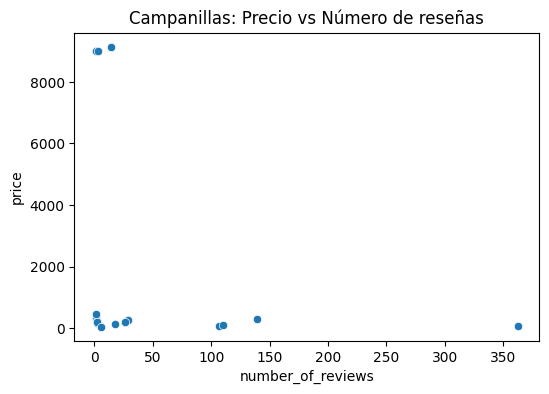

In [8]:
df_campanillas = df[df["neighbourhood"]=="Campanillas"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df[df["neighbourhood"]=="Campanillas"],
    x="number_of_reviews",
    y="price"
)
plt.title("Campanillas: Precio vs Número de reseñas")
plt.show()


In [ ]:
# El análisis del precio frente al número de reseñas en Campanillas muestra que los valores extremadamente altos corresponden a 
# alojamientos con muy poca actividad (casi sin reseñas). Estos puntos actúan como outliers y distorsionan la media del barrio. 
# La mayoría de alojamientos tienen precios moderados, por lo que el precio medio elevado de Campanillas no refleja una tendencia real, 
# sino la presencia de unos pocos alojamientos atípicos.

In [14]:
df_campanillas[["price", "number_of_reviews", "availability_365"]].describe()


,price,number_of_reviews,availability_365
count,19.000000,19.000000,19.000000
mean,2989.210526,43.578947,287.210526
std,4213.307682,88.398916,95.501355
min,56.000000,1.000000,57.000000
25%,157.500000,1.500000,225.500000
50%,259.000000,3.000000,354.000000
75%,9000.000000,27.500000,363.000000
max,9143.000000,363.000000,364.000000


In [ ]:
# De esta tabla podemos deducir que solo hay 19 alojamientos en Campanillas, lo que representa un 0.27 % de los alojamientos disponibles 
# en Málaga, el 50% de esos 19 alojamientos están a un precio de 259 €. Vamos a ver cuales son los alojamientos que están por encima del Q3

In [17]:
# vamos a calcular cuales son esos outliers
df_campanillas["price"].quantile(0.75)


np.float64(9000.0)

In [20]:
outliers_Q3 = df_campanillas[df_campanillas["price"] > Q3]

outliers_Q3


,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
4317,Limón Lunero,544263779,Michael,Campanillas,Entire home/apt,9143.0,1,14,2025-08-18,0.69,3,354,10,VFT/MA/62520


In [ ]:
# Este alojamiento no nos devuelve un valor real está muy por encima de la media, puede ser un error en los datos

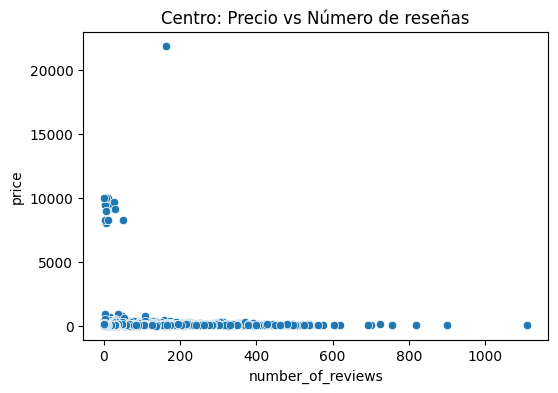

In [21]:
df_centro = df[df["neighbourhood"]=="Centro"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df[df["neighbourhood"]=="Centro"],
    x="number_of_reviews",
    y="price"
)
plt.title("Centro: Precio vs Número de reseñas")
plt.show()

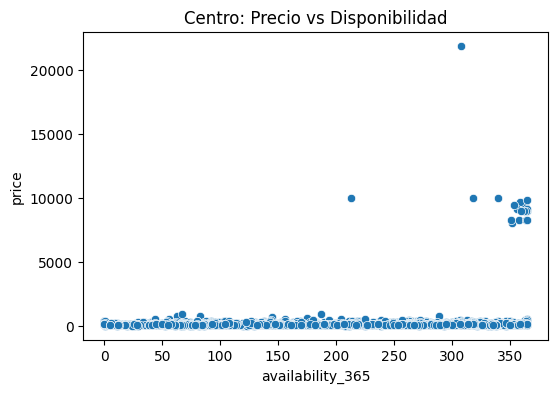

In [29]:
df_centro = df[df["neighbourhood"]=="Centro"]

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df[df["neighbourhood"]=="Centro"],
    x="availability_365",
    y="price"
)
plt.title("Centro: Precio vs Disponibilidad")
plt.show()

In [23]:
def clasificar_disponibilidad(x):
    if x == 0:
        return "0 días"
    elif x <= 30:
        return "1-30 días"
    elif x <= 90:
        return "31-90 días"
    elif x <= 180:
        return "91-180 días"
    else:
        return "181-365 días"


In [24]:
df["disponibilidad_rango"] = df["availability_365"].apply(clasificar_disponibilidad)


In [26]:
df

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,disponibilidad_rango
0,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,Este,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...,181-365 días
1,Perfect Location In Malaga,793360,Fred,Este,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN,181-365 días
2,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,Centro,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...,31-90 días
3,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,Centro,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334,181-365 días
4,Casa La Maga - Apartment for happy people,1526932,Cristina,Centro,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288,181-365 días
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6856,Casa de Lara,704883083,María José,Cruz De Humilladero,Entire home/apt,62.0,1,2,2025-09-28,2.00,1,81,2,VUT/MA/97675<br />EDFTU0000290260001245410,31-90 días
6857,Sky Nueva,667738222,Luis Enrique,Centro,Entire home/apt,89.0,1,1,2025-09-23,1.00,9,78,1,VUT/MA/68250,31-90 días
6858,Soho Vibes by Living4Malaga,94173177,Living4Malaga,Centro,Entire home/apt,173.0,1,1,2025-09-28,1.00,125,359,1,-,181-365 días
6859,Homeclub | Stunning Views from the 21st Floor,570694659,Alejandra Margarita,Palma-Palmilla,Entire home/apt,276.0,1,1,2025-09-26,1.00,1,351,1,ESFCTU0000290240010479060000000000000000VUT/MA...,181-365 días


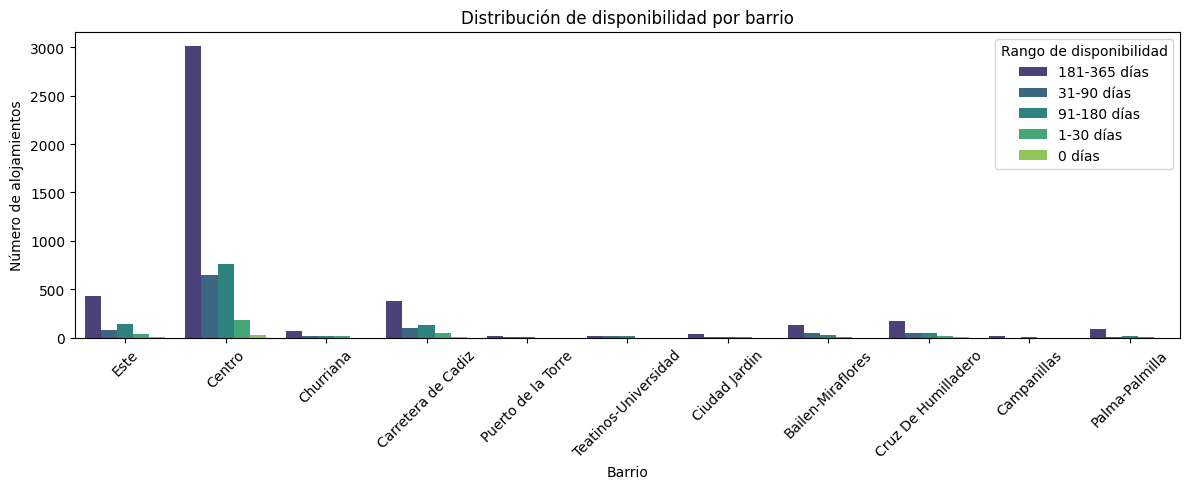

In [ ]:
# Disponibilidad por barrio

plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x="neighbourhood",
    hue="disponibilidad_rango",
    palette="viridis"
)
plt.title("Distribución de disponibilidad por barrio")
plt.xlabel("Barrio")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=45)
plt.legend(title="Rango de disponibilidad")
plt.tight_layout()
plt.show()


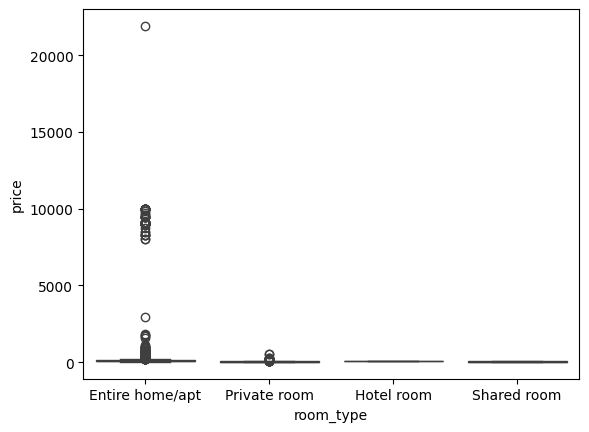

In [ ]:
## Nueva hipótesis 2: El tipo de alojamiento influye más que el barrio

sns.boxplot(data=df, x="room_type", y="price");

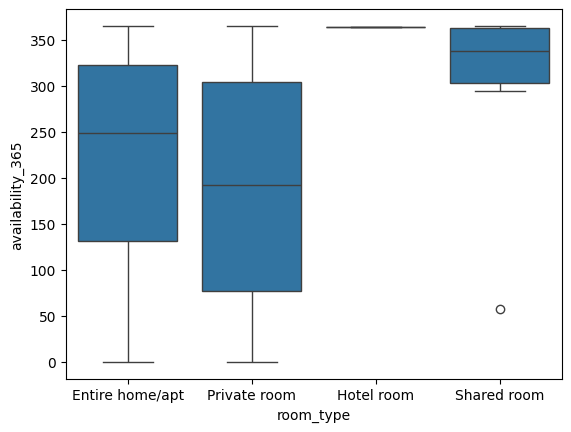

In [32]:
sns.boxplot(data=df, x="room_type", y="availability_365");


In [ ]:
# El análisis muestra que la disponibilidad está fuertemente influida por el tipo de alojamiento. Los apartamentos completos presentan una 
# disponibilidad significativamente mayor, lo que sugiere menor rotación y menor demanda relativa debido a su precio más elevado. 
# Por el contrario, las habitaciones privadas muestran menor disponibilidad, indicando mayor demanda y mayor frecuencia de reservas. 
# Este patrón confirma que la disponibilidad no depende únicamente del barrio, sino del tipo de alojamiento.